In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install timm opencv-python medpy -q

In [ ]:
!pip install medpy -q

In [ ]:
import os
import cv2
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.model_selection import train_test_split
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from timm.models.layers import DropPath

/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [ ]:
class CFG:
    seed = 42
    image_size = 256
    batch_size = 4
    num_workers = 2
    epochs = 50
    lr = 1e-3
    device = "cuda" if torch.cuda.is_available() else "cpu"

    drive_root = "/content/drive/MyDrive/DRIVE"

    image_dir = os.path.join(drive_root, "training", "images")
    mask_dir  = os.path.join(drive_root, "training", "1st_manual")

cfg = CFG()

print("Device:", cfg.device)
print("Image dir:", cfg.image_dir)
print("Mask dir :", cfg.mask_dir)

Device: cpu
Image dir: /content/drive/MyDrive/DRIVE/training/images
Mask dir : /content/drive/MyDrive/DRIVE/training/1st_manual


In [ ]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(cfg.seed)

In [ ]:
VALID_EXTS = {".png", ".jpg", ".jpeg", ".tif", ".tiff", ".gif", ".bmp"}

def list_all_files(folder):
    folder = Path(folder)
    if not folder.exists():
        return []
    return sorted([str(x) for x in folder.iterdir() if x.is_file() and x.suffix.lower() in VALID_EXTS])

image_files = list_all_files(cfg.image_dir)
mask_files  = list_all_files(cfg.mask_dir)

print("Images:", len(image_files))
print("Masks :", len(mask_files))

print("\nSample image files:", image_files[:3])
print("Sample mask files :", mask_files[:3])

Images: 20
Masks : 20

Sample image files: ['/content/drive/MyDrive/DRIVE/training/images/21_training.tif', '/content/drive/MyDrive/DRIVE/training/images/22_training.tif', '/content/drive/MyDrive/DRIVE/training/images/23_training.tif']
Sample mask files : ['/content/drive/MyDrive/DRIVE/training/1st_manual/21_manual1.gif', '/content/drive/MyDrive/DRIVE/training/1st_manual/22_manual1.gif', '/content/drive/MyDrive/DRIVE/training/1st_manual/23_manual1.gif']


In [ ]:
def get_case_id(path):
    name = Path(path).stem.lower()
    name = name.replace("_training", "")
    name = name.replace("_manual1", "")
    name = name.replace("_manual2", "")
    return name

def build_pairs(image_files, mask_files):
    mask_dict = {get_case_id(m): m for m in mask_files}
    pairs = []
    missing = []

    for img in image_files:
        key = get_case_id(img)
        if key in mask_dict:
            pairs.append((img, mask_dict[key]))
        else:
            missing.append(img)

    return pairs, missing

pairs, missing = build_pairs(image_files, mask_files)

print("Matched pairs:", len(pairs))

if missing:
    print("\nMissing masks:")
    for x in missing[:5]:
        print(x)

Matched pairs: 20


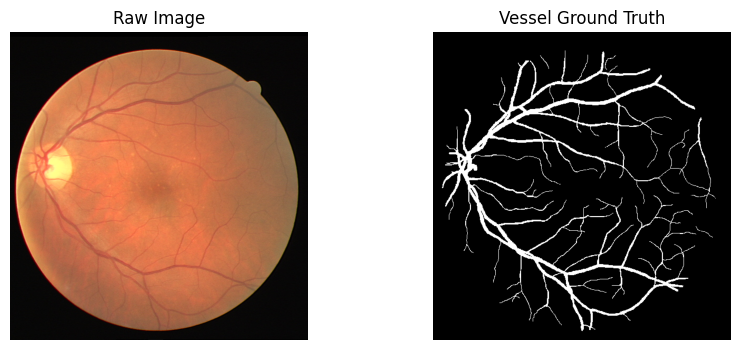

In [ ]:
img_path, mask_path = pairs[0]

img = cv2.imread(img_path, cv2.IMREAD_COLOR)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title("Raw Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mask, cmap="gray")
plt.title("Vessel Ground Truth")
plt.axis("off")

plt.show()

In [ ]:
train_pairs, temp_pairs = train_test_split(
    pairs,
    test_size=0.3,
    random_state=cfg.seed
)

val_pairs, test_pairs = train_test_split(
    temp_pairs,
    test_size=0.5,
    random_state=cfg.seed
)

print("Train pairs:", len(train_pairs))
print("Validation pairs:", len(val_pairs))
print("Test pairs:", len(test_pairs))

Train pairs: 14
Validation pairs: 3
Test pairs: 3


In [ ]:
class DriveDataset(Dataset):
    def __init__(self, pairs, image_size=256):
        self.pairs = pairs
        self.image_size = image_size
        self.clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

    def __len__(self):
        return len(self.pairs)

    def preprocess_image(self, img):
        # BGR -> RGB
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # green channel
        green = img[:, :, 1]

        # CLAHE
        green = self.clahe.apply(green)

        # normalize
        green = green.astype(np.float32) / 255.0

        # make 3 channels again
        green = np.stack([green, green, green], axis=0)
        return green

    def __getitem__(self, idx):
        img_path, mask_path = self.pairs[idx]

        img = cv2.imread(img_path, cv2.IMREAD_COLOR)
        img = cv2.resize(img, (self.image_size, self.image_size))
        img = self.preprocess_image(img)

        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        mask = cv2.resize(mask, (self.image_size, self.image_size))
        mask = (mask > 0).astype(np.float32)
        mask = np.expand_dims(mask, axis=0)

        return torch.tensor(img, dtype=torch.float32), torch.tensor(mask, dtype=torch.float32)

In [ ]:
train_dataset = DriveDataset(train_pairs, cfg.image_size)
val_dataset   = DriveDataset(val_pairs, cfg.image_size)
test_dataset  = DriveDataset(test_pairs, cfg.image_size)

print("Train dataset:", len(train_dataset))
print("Val dataset  :", len(val_dataset))
print("Test dataset :", len(test_dataset))

Train dataset: 14
Val dataset  : 3
Test dataset : 3


In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=cfg.batch_size,
    shuffle=True,
    num_workers=cfg.num_workers
)

val_loader = DataLoader(
    val_dataset,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=cfg.num_workers
)

test_loader = DataLoader(
    test_dataset,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=cfg.num_workers
)

print("Train batches:", len(train_loader))
print("Val batches  :", len(val_loader))
print("Test batches :", len(test_loader))

Train batches: 4
Val batches  : 1
Test batches : 1


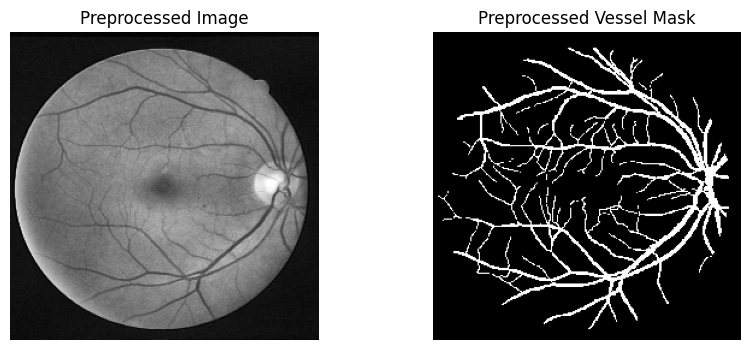

In [ ]:
img, mask = train_dataset[0]

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(img.permute(1, 2, 0).numpy(), cmap="gray")
plt.title("Preprocessed Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mask.squeeze().numpy(), cmap="gray")
plt.title("Preprocessed Vessel Mask")
plt.axis("off")

plt.show()

In [ ]:
class DiceBCELoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()

    def forward(self, pred, target, smooth=1e-6):
        bce = self.bce(pred, target)
        pred_sig = torch.sigmoid(pred)

        intersection = (pred_sig * target).sum(dim=(1, 2, 3))
        union = pred_sig.sum(dim=(1, 2, 3)) + target.sum(dim=(1, 2, 3))
        dice_loss = 1 - ((2.0 * intersection + smooth) / (union + smooth)).mean()

        return bce + dice_loss

In [ ]:
def compute_metrics(pred, target):
    pred = torch.sigmoid(pred)
    pred = (pred > 0.5).float()
    target = target.float()

    tp = (pred * target).sum()
    fp = (pred * (1 - target)).sum()
    fn = ((1 - pred) * target).sum()
    tn = ((1 - pred) * (1 - target)).sum()

    dice = (2 * tp) / (2 * tp + fp + fn + 1e-6)
    jaccard = tp / (tp + fp + fn + 1e-6)
    accuracy = (tp + tn) / (tp + tn + fp + fn + 1e-6)
    precision = tp / (tp + fp + 1e-6)
    recall = tp / (tp + fn + 1e-6)

    return {
        "dice": dice.item(),
        "jaccard": jaccard.item(),
        "accuracy": accuracy.item(),
        "precision": precision.item(),
        "recall": recall.item(),
    }

In [ ]:
import torch
import torch.nn as nn

class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.conv(x)


class UNet(nn.Module):
    def __init__(self, in_ch=3, out_ch=1):
        super().__init__()

        self.enc1 = DoubleConv(in_ch, 64)
        self.enc2 = DoubleConv(64, 128)
        self.enc3 = DoubleConv(128, 256)
        self.enc4 = DoubleConv(256, 512)

        self.pool = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(512, 1024)

        self.up4 = nn.ConvTranspose2d(1024, 512, 2, stride=2)
        self.dec4 = DoubleConv(1024, 512)

        self.up3 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec3 = DoubleConv(512, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec2 = DoubleConv(256, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec1 = DoubleConv(128, 64)

        self.final = nn.Conv2d(64, out_ch, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))

        b = self.bottleneck(self.pool(e4))

        d4 = self.up4(b)
        d4 = torch.cat([d4, e4], dim=1)
        d4 = self.dec4(d4)

        d3 = self.up3(d4)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        return self.final(d1)

In [ ]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [ ]:
model = UNet(in_ch=3, out_ch=1).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=cfg.lr)
criterion = DiceBCELoss()

In [ ]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0

    for imgs, masks in loader:
        imgs = imgs.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()
        preds = model(imgs)
        loss = criterion(preds, masks)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

In [ ]:
def evaluate(model, loader, criterion, device):
    model.eval()

    total_loss = 0.0
    metrics_sum = {
        "dice": 0.0,
        "jaccard": 0.0,
        "accuracy": 0.0,
        "precision": 0.0,
        "recall": 0.0
    }

    with torch.no_grad():
        for imgs, masks in loader:
            imgs = imgs.to(device)
            masks = masks.to(device)

            preds = model(imgs)
            loss = criterion(preds, masks)
            total_loss += loss.item()

            metrics = compute_metrics(preds, masks)

            for k in metrics_sum:
                metrics_sum[k] += metrics[k]

    for k in metrics_sum:
        metrics_sum[k] /= len(loader)

    metrics_sum["loss"] = total_loss / len(loader)
    return metrics_sum

In [ ]:
history = []
best_dice = 0.0
save_path = "/content/drive/MyDrive/DRIVE/best_unet_drive.pth"

for epoch in range(cfg.epochs):
    print(f"\nEpoch [{epoch+1}/{cfg.epochs}]")

    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, cfg.device)
    val_metrics = evaluate(model, val_loader, criterion, cfg.device)

    row = {
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "val_loss": val_metrics["loss"],
        "dice": val_metrics["dice"],
        "jaccard": val_metrics["jaccard"],
        "accuracy": val_metrics["accuracy"],
        "precision": val_metrics["precision"],
        "recall": val_metrics["recall"],
    }
    history.append(row)
    print(row)

    if val_metrics["dice"] > best_dice:
        best_dice = val_metrics["dice"]
        torch.save(model.state_dict(), save_path)
        print("Saved best model")


Epoch [1/50]
{'epoch': 1, 'train_loss': 1.2158990502357483, 'val_loss': 1.4062037467956543, 'dice': 0.0, 'jaccard': 0.0, 'accuracy': 0.8675486445426941, 'precision': 0.0, 'recall': 0.0}

Epoch [2/50]
{'epoch': 2, 'train_loss': 0.9553976953029633, 'val_loss': 1.3452047109603882, 'dice': 0.0, 'jaccard': 0.0, 'accuracy': 0.8675486445426941, 'precision': 0.0, 'recall': 0.0}

Epoch [3/50]
{'epoch': 3, 'train_loss': 0.8988101482391357, 'val_loss': 1.367314100265503, 'dice': 0.2479233592748642, 'jaccard': 0.14150257408618927, 'accuracy': 0.7655995488166809, 'precision': 0.2155749797821045, 'recall': 0.29169386625289917}
Saved best model

Epoch [4/50]
{'epoch': 4, 'train_loss': 0.8653828501701355, 'val_loss': 1.2729320526123047, 'dice': 0.0008444649283774197, 'jaccard': 0.0004224108124617487, 'accuracy': 0.8676045536994934, 'precision': 0.9999999403953552, 'recall': 0.0004224108124617487}

Epoch [5/50]
{'epoch': 5, 'train_loss': 0.8115795403718948, 'val_loss': 1.2707304954528809, 'dice': 0.00

In [ ]:
model.load_state_dict(torch.load(save_path, map_location=cfg.device))
model.eval()
print("Best model loaded")

Best model loaded


In [ ]:
test_metrics = evaluate(model, test_loader, criterion, cfg.device)
test_results_df = pd.DataFrame([test_metrics])
test_results_df

,dice,jaccard,accuracy,precision,recall,loss
0,0.796698,0.662093,0.951146,0.753735,0.844855,0.399013


In [ ]:
import pandas as pd

history_df = pd.DataFrame(history)
history_df

,epoch,train_loss,val_loss,dice,jaccard,accuracy,precision,recall
0,1,1.215899,1.406204,0.000000,0.000000,0.867549,0.000000,0.000000
1,2,0.955398,1.345205,0.000000,0.000000,0.867549,0.000000,0.000000
2,3,0.898810,1.367314,0.247923,0.141503,0.765600,0.215575,0.291694
3,4,0.865383,1.272932,0.000844,0.000422,0.867605,1.000000,0.000422
4,5,0.811580,1.270730,0.003752,0.001880,0.867650,0.628205,0.001882
5,6,0.778970,1.278348,0.004133,0.002071,0.867650,0.613636,0.002074
6,7,0.751319,1.306257,0.004467,0.002239,0.866247,0.157754,0.002266
7,8,0.733861,1.249199,0.023127,0.011699,0.868088,0.604331,0.011789
8,9,0.702221,1.122280,0.195434,0.108300,0.877045,0.733084,0.112745
9,10,0.667169,0.854483,0.593048,0.421512,0.911397,0.757113,0.487424


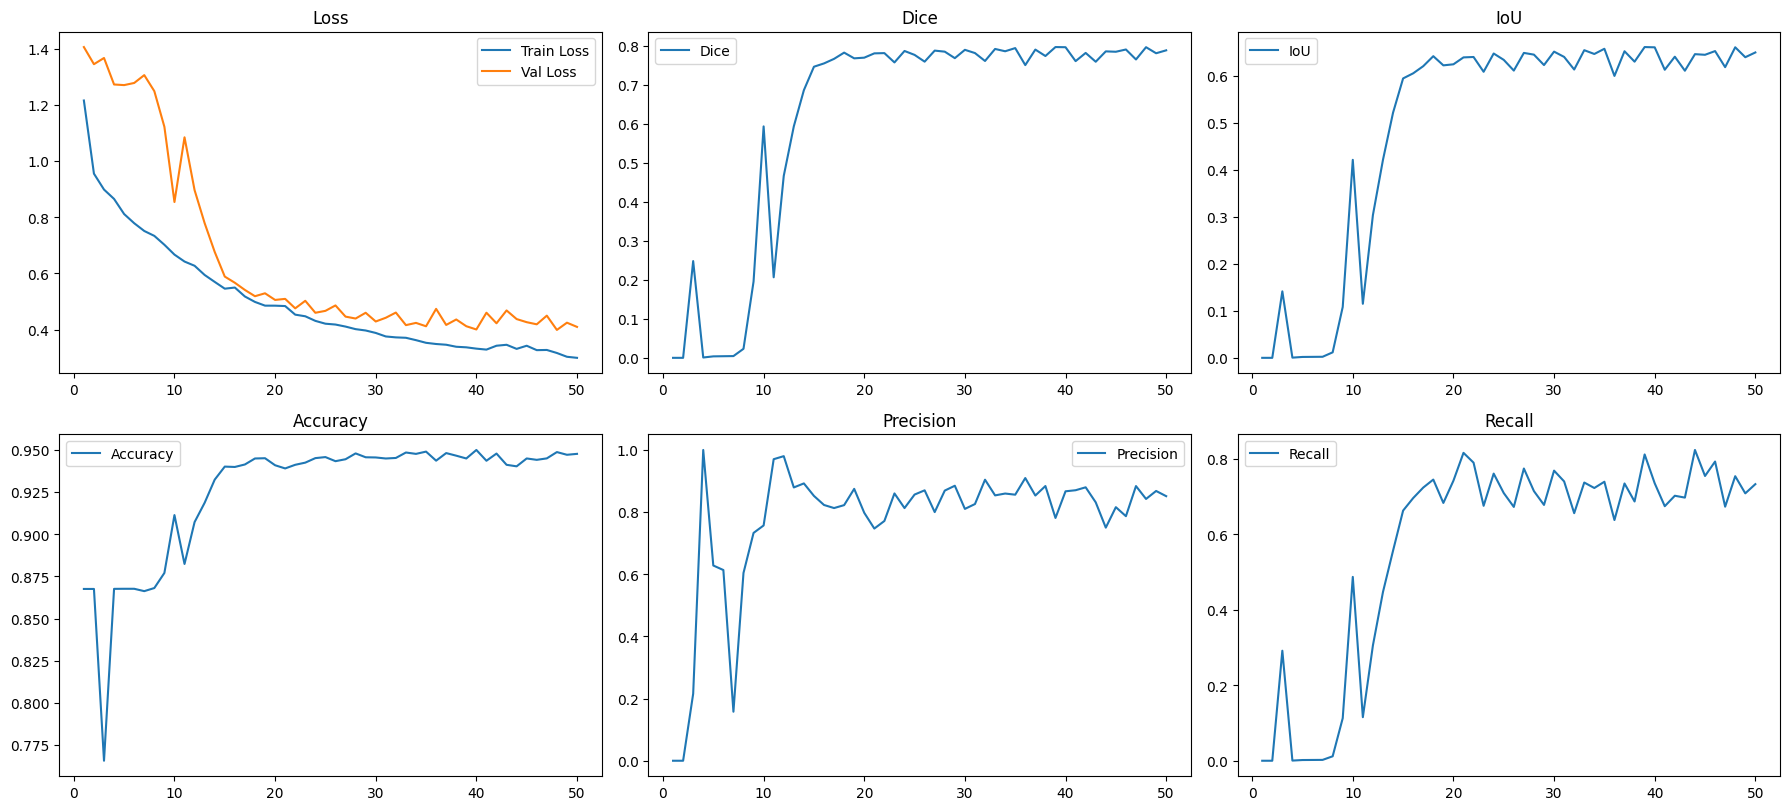

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 12))

# ---- Loss ----
plt.subplot(3,3,1)
plt.plot(history_df["epoch"], history_df["train_loss"], label="Train Loss")
plt.plot(history_df["epoch"], history_df["val_loss"], label="Val Loss")
plt.legend()
plt.title("Loss")

# ---- Dice ----
plt.subplot(3,3,2)
plt.plot(history_df["epoch"], history_df["dice"], label="Dice")
plt.legend()
plt.title("Dice")

# ---- IoU ----
plt.subplot(3,3,3)
plt.plot(history_df["epoch"], history_df["jaccard"], label="IoU")
plt.legend()
plt.title("IoU")

# ---- Accuracy ----
plt.subplot(3,3,4)
plt.plot(history_df["epoch"], history_df["accuracy"], label="Accuracy")
plt.legend()
plt.title("Accuracy")

# ---- Precision ----
plt.subplot(3,3,5)
plt.plot(history_df["epoch"], history_df["precision"], label="Precision")
plt.legend()
plt.title("Precision")

# ---- Recall ----
plt.subplot(3,3,6)
plt.plot(history_df["epoch"], history_df["recall"], label="Recall")
plt.legend()
plt.title("Recall")

plt.tight_layout()
plt.show()

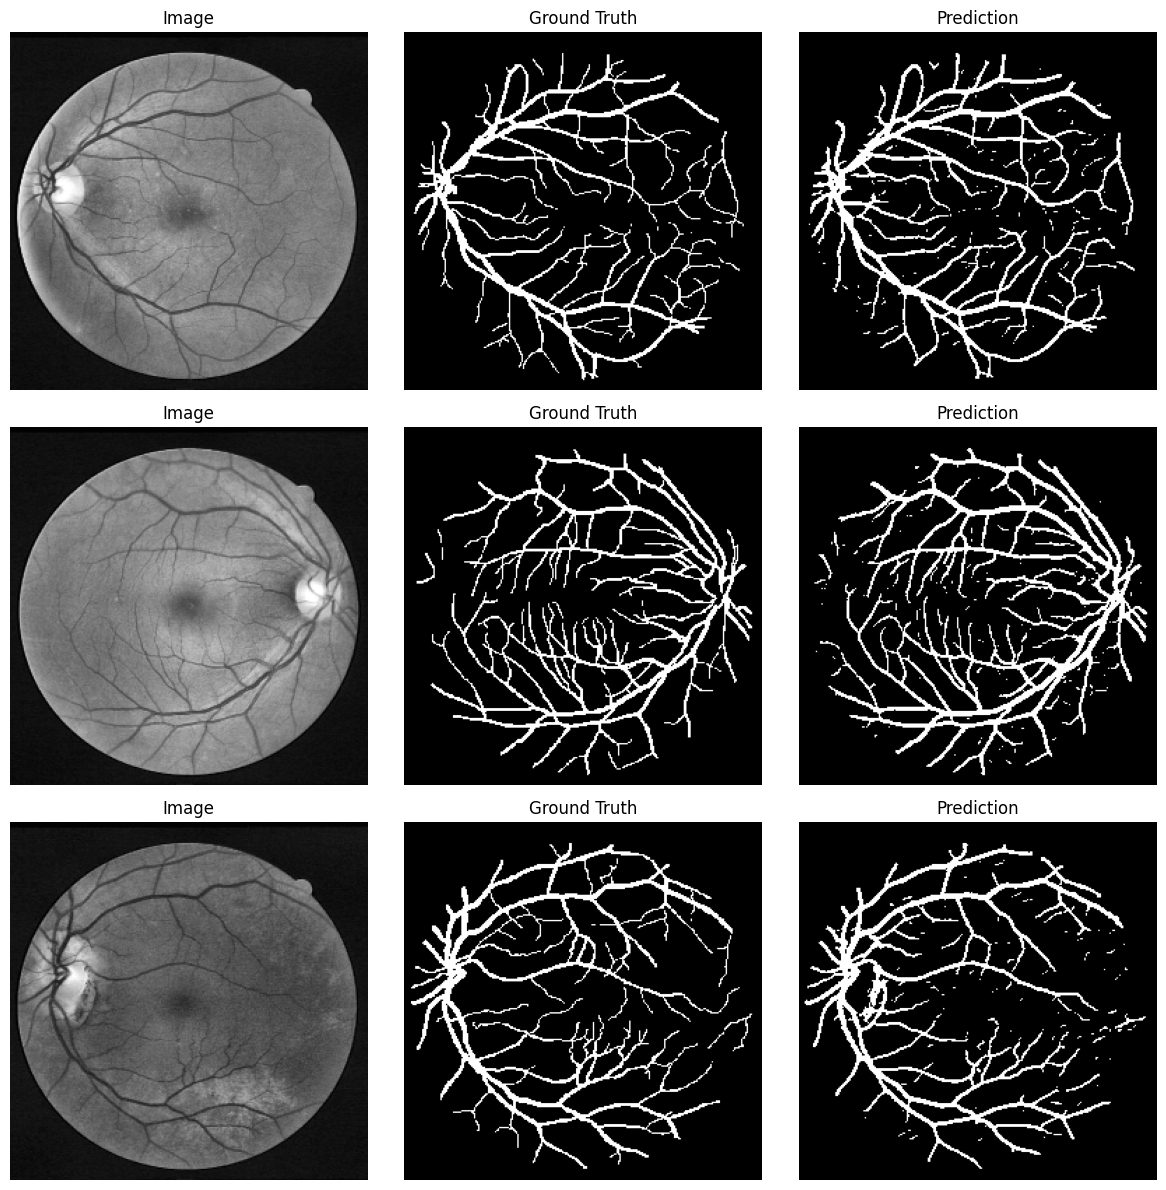

In [ ]:
def show_predictions(model, dataset, device, num_samples=3):
    model.eval()
    idxs = np.random.choice(len(dataset), num_samples, replace=False)

    plt.figure(figsize=(12, 4 * num_samples))

    with torch.no_grad():
        for i, idx in enumerate(idxs):
            image, mask = dataset[idx]
            image_input = image.unsqueeze(0).to(device)

            pred = model(image_input)
            pred = torch.sigmoid(pred).squeeze().cpu().numpy()
            pred = (pred > 0.5).astype(np.uint8)

            img_np = image[0].cpu().numpy()
            mask_np = mask.squeeze().cpu().numpy()

            plt.subplot(num_samples, 3, i*3+1)
            plt.imshow(img_np, cmap="gray")
            plt.title("Image")
            plt.axis("off")

            plt.subplot(num_samples, 3, i*3+2)
            plt.imshow(mask_np, cmap="gray")
            plt.title("Ground Truth")
            plt.axis("off")

            plt.subplot(num_samples, 3, i*3+3)
            plt.imshow(pred, cmap="gray")
            plt.title("Prediction")
            plt.axis("off")

    plt.tight_layout()
    plt.show()

show_predictions(model, test_dataset, cfg.device, num_samples=3)